# Controllo: dati con α = 4.4 analizzati con il modello CORRETTO (α = 4.4)

Stessi dati dei notebook 07 e 08 (`sim_data_noise_sv44/`), ma qui la likelihood usa lo stesso indice cromatico della simulazione, α = 4.4. Il modello è quindi corretto e ha 6 parametri.

Serve come termine di paragone ideale:
1. se i parametri tornano ai valori veri, lo spostamento di +0.44 dex su `sv_gp_log10_A` visto nel notebook 07 è dovuto **solo** all'α sbagliato, e non a un problema della simulazione o della pipeline;
2. dà il riferimento per giudicare quanto costa, in precisione, lasciare α libero (notebook 08).

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`.

In [2]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

Optional mpi4py package is not installed.  MPI support is not available.


In [3]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [4]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [5]:
logL = ds.PulsarLikelihood(model).logL

In [6]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [7]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  4.87694144, -13.30053766,   4.63775145, -16.95998957,
         0.57913849, -17.43402997])

In [8]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catena di confronto (letta da disco, nessun sampling)

- `chain_sim_sv44`: stessi dati, analizzati con α **fisso a 4.0**, modello errato (notebook 07)

In [9]:
chain_sim_sv44 = np.loadtxt('./test_sim_sv44/chain_1.txt')[:, :-4]
chain_sim_sv44 = chain_sim_sv44[len(chain_sim_sv44)//4:]   # rimuovo il 25% di burn-in
chain_sim_sv44.shape

(75001, 6)

## Dati simulati con scattering α = 4.4

In [10]:
sim_sv44_psr = ds.pulsar.Pulsar.read_feather('sim_data_noise_sv44/J1640+2224')
print('nome     :', sim_sv44_psr.name)
print('N_TOA    :', len(sim_sv44_psr.toas))

nome     : J1640+2224
N_TOA    : 6777


## Analisi con il modello corretto (scattering α = 4.4)

In [11]:
# identico al notebook 07, tranne alpha nella riga sv_gp: 4.4 invece di 4.0
model_sim_sv44_ok = [sim_sv44_psr.residuals]
model_sim_sv44_ok += [ds.makegp_timing(sim_sv44_psr, svd=True)]
model_sim_sv44_ok += [ds.makenoise_measurement(sim_sv44_psr, sim_sv44_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_sv44_ok.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_red_components'],
                                           T=ds.getspan(sim_sv44_psr), name='red_noise'))
model_sim_sv44_ok.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_dm_components'],
                                           T=ds.getspan(sim_sv44_psr), name='dm_gp',
                                           fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_sv44_ok.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_chrom_components'],
                                           T=ds.getspan(sim_sv44_psr), name='sv_gp',
                                           fourierbasis=ds.make_dmfourierbasis(alpha=4.4, tndm=False)))   # <-- 4.4, come nella simulazione

logL_sim_sv44_ok = ds.PulsarLikelihood(model_sim_sv44_ok).logL
logL_sim_sv44_ok.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [12]:
# controllo: stessi parametri e stesso ordine dell'analisi reale (alpha resta FISSO, non e' un parametro)
assert list(logL_sim_sv44_ok.params) == list(logL.params), (logL_sim_sv44_ok.params, logL.params)
print('OK: 6 parametri, identici a logL.params')

OK: 6 parametri, identici a logL.params


In [13]:
def params_dict_from_array_sim_sv44_ok(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_sv44_ok.params, x))

priors_sim_sv44_ok = build_priors(logL_sim_sv44_ok.params, my_priordict)

def log_prior_sim_sv44_ok(x):
    params = params_dict_from_array_sim_sv44_ok(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_sv44_ok:
            logp += priors_sim_sv44_ok[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_sv44_ok():
    return np.array([priors_sim_sv44_ok[name].rvs() for name in logL_sim_sv44_ok.params])

x0_sim_sv44_ok = prior_draw_sim_sv44_ok()

In [14]:
@jax.jit
def _jit_logL_sim_sv44_ok(params_array):
    return logL_sim_sv44_ok(dict(zip(logL_sim_sv44_ok.params, params_array)))

def log_likelihood_sim_sv44_ok(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_sv44_ok(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_sv44_ok(x0_sim_sv44_ok))

# tempo di una valutazione: con alpha FISSO i prodotti FtN^-1F sono precalcolati, quindi e' veloce
start = time.time()
for _ in range(20):
    log_likelihood_sim_sv44_ok(x0_sim_sv44_ok)
dt = (time.time() - start) / 20
print(f'una valutazione = {dt*1e3:.1f} ms  ->  10^6 iterazioni ~ {dt*1e6/3600:.1f} ore (solo likelihood)')

logL iniziale = 67502.10803694137
una valutazione = 1.2 ms  ->  10^6 iterazioni ~ 0.3 ore (solo likelihood)


In [14]:
sampler_sim_sv44_ok = ptmcmc(
    ndim=len(logL_sim_sv44_ok.params),
    logl=log_likelihood_sim_sv44_ok,
    logp=log_prior_sim_sv44_ok,
    cov=np.eye(len(logL_sim_sv44_ok.params)) * 0.001,
    outDir='./test_sim_sv44_alpha44/',
    resume=True
)

### Sampling

Eseguire **una sola volta**. Con α fisso il costo per passo è quello solito dei run a 6 parametri, e τ è piccolo (~6): se vuoi accorciare, 2×10⁵ iterazioni bastano già per ESS ≈ 2000. Per confrontabilità con il notebook 07 qui restano 10⁶.

In [15]:
print("Starting sampling (sim con scattering alpha=4.4, analizzata con alpha=4.4, modello CORRETTO)...")
sampler_sim_sv44_ok.sample(x0_sim_sv44_ok, Niter=1000000, thin=10)

Starting sampling (sim con scattering alpha=4.4, analizzata con alpha=4.4, modello CORRETTO)...
Finished 1.00 percent (1.00 percent of new work) in 13.156378 s Acceptance rate = 0.2352Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 8532.139893 s Acceptance rate = 0.349607
Run Complete


## Catena e grafici

In [15]:
chain_sim_sv44_ok = np.loadtxt('./test_sim_sv44_alpha44/chain_1.txt')[:, :-4]
chain_sim_sv44_ok = chain_sim_sv44_ok[len(chain_sim_sv44_ok)//4:]   # rimuovo il 25% di burn-in
chain_sim_sv44_ok.shape

(75001, 6)

In [16]:
import emcee
tau_ok = emcee.autocorr.integrated_time(chain_sim_sv44_ok, has_walkers=False, quiet=True)
print('tau =', np.round(tau_ok, 1))
print('Effective length =', int(len(chain_sim_sv44_ok) / tau_ok.max()))

tau = [3.8 3.9 4.8 2.6 4.2 3.8]
Effective length = 15744


In [17]:
# riepilogo numerico: recupero dei valori veri con il modello corretto
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_sv44_ok.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_sv44_ok.params]

print(f"{'parametro':20s} {'vero':>9s} | {'mediana [16, 84]':>28s} | scarto/sigma")
for i, name in enumerate(logL_sim_sv44_ok.params):
    q16, q50, q84 = np.percentile(chain_sim_sv44_ok[:, i], [16, 50, 84])
    sigma = (q84 - q16) / 2
    print(f"{name.replace('J1640+2224_', ''):20s} {truths_dict[name]:9.3f} | {q50:9.3f} [{q16:8.3f}, {q84:8.3f}] | {(q50 - truths_dict[name]) / sigma:6.2f}")

parametro                 vero |             mediana [16, 84] | scarto/sigma
dm_gp_gamma              6.471 |     5.043 [   3.922,    6.176] |  -1.27
dm_gp_log10_A          -15.723 |   -14.955 [ -15.413,  -14.526] |   1.73
red_noise_gamma          0.132 |     0.217 [   0.062,    0.471] |   0.41
red_noise_log10_A      -13.213 |   -13.240 [ -13.318,  -13.165] |  -0.35
sv_gp_gamma              1.326 |     1.422 [   1.239,    1.621] |   0.50
sv_gp_log10_A          -15.888 |   -15.811 [ -15.853,  -15.767] |   1.81


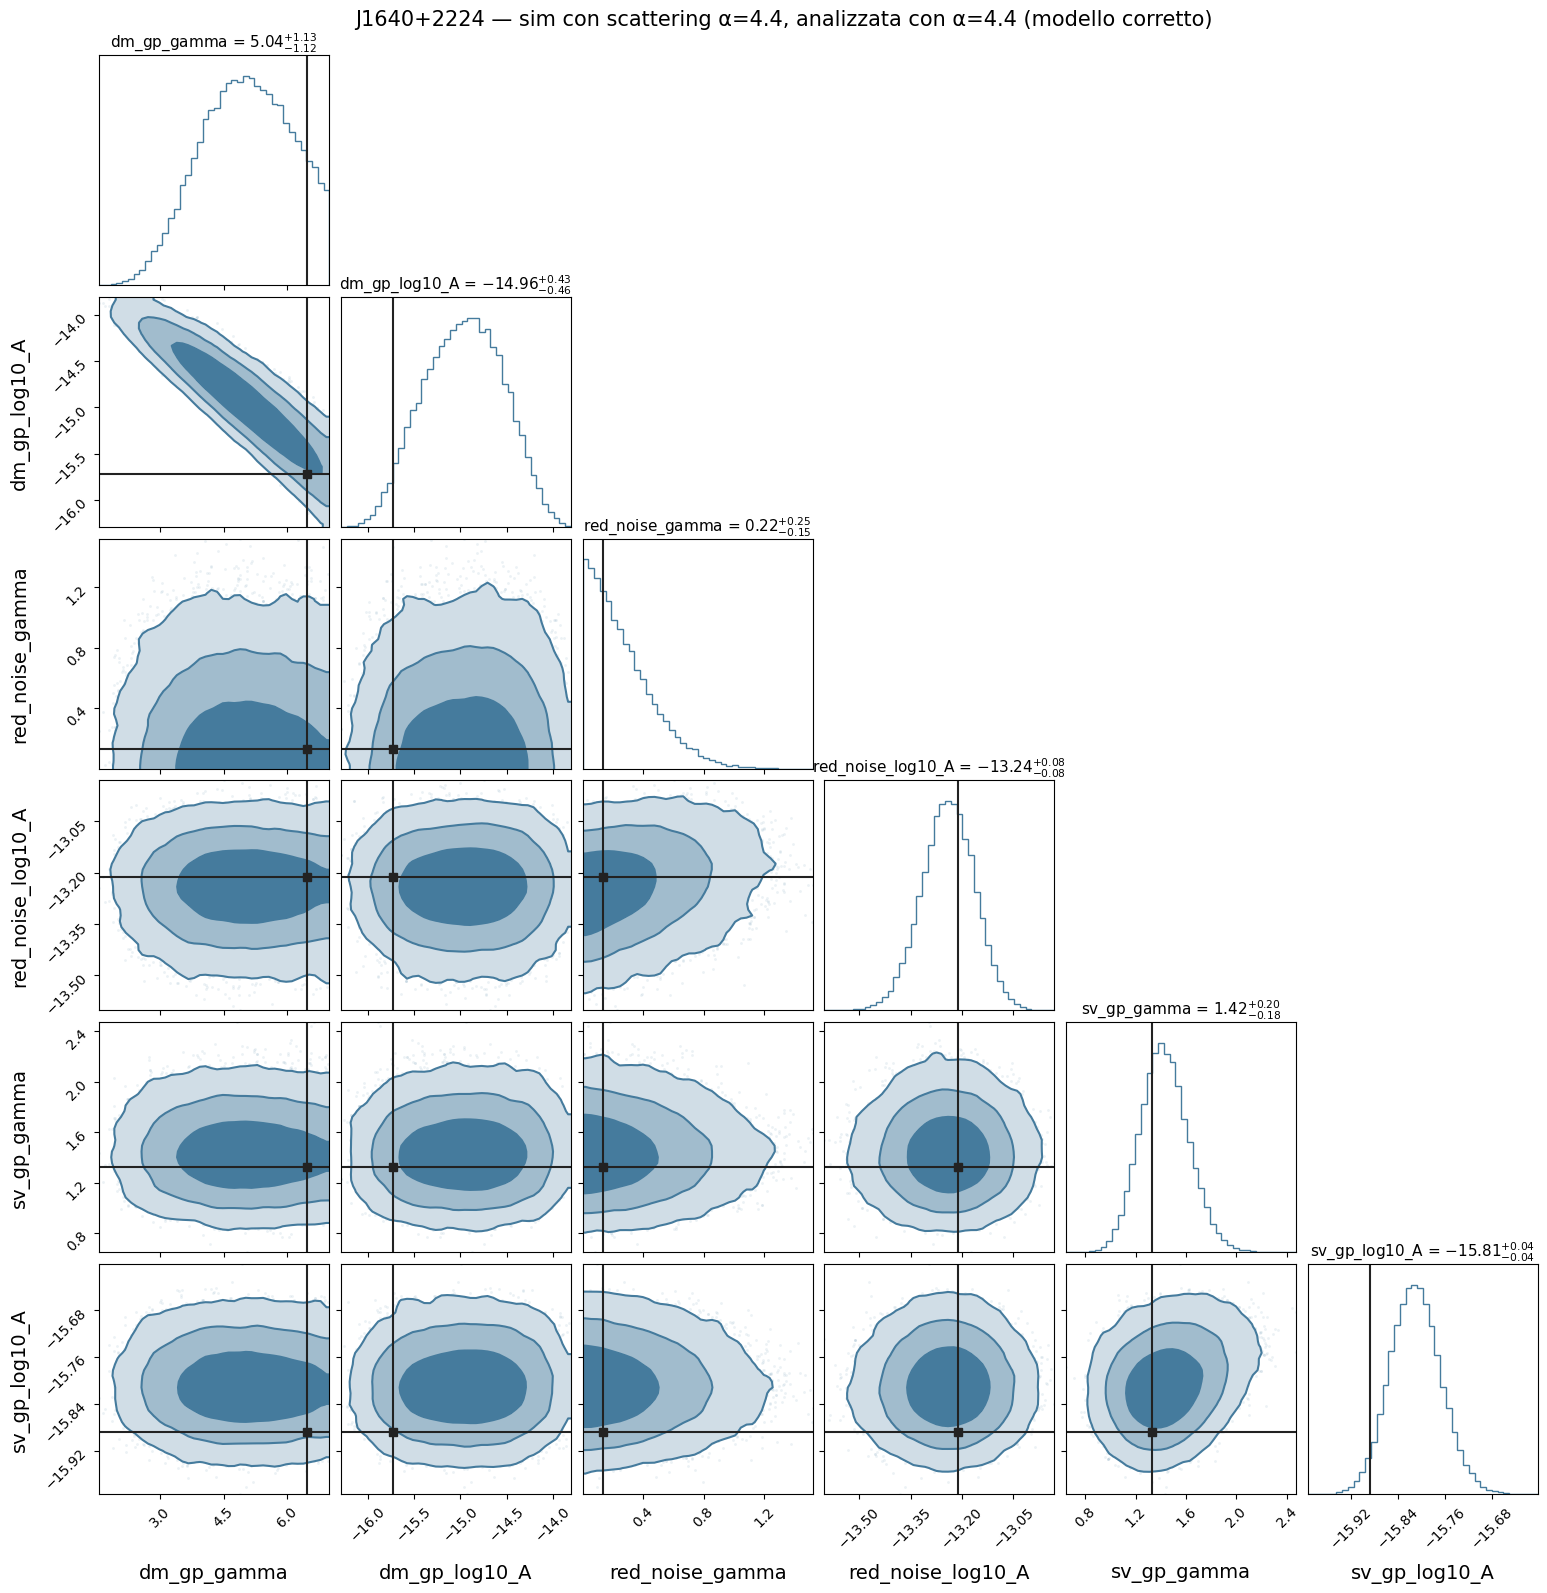

In [18]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_sv44_ok.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_sv44_ok.params]

fig = corner.corner(
    chain_sim_sv44_ok,
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#457B9D',
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim con scattering α=4.4, analizzata con α=4.4 (modello corretto)', fontsize=15, y=1.00)
fig.savefig('corner_sim_sv44_alpha44_corretto.png', dpi=150, bbox_inches='tight')

### Confronto: modello errato (α = 4.0) vs modello corretto (α = 4.4)

Stessi dati, stesso seed: l'unica differenza è l'indice cromatico usato nell'analisi. Atteso: la curva blu (corretto) centrata sui valori veri, la arancio (errato) spostata di circa +0.44 dex su `sv_gp_log10_A`.

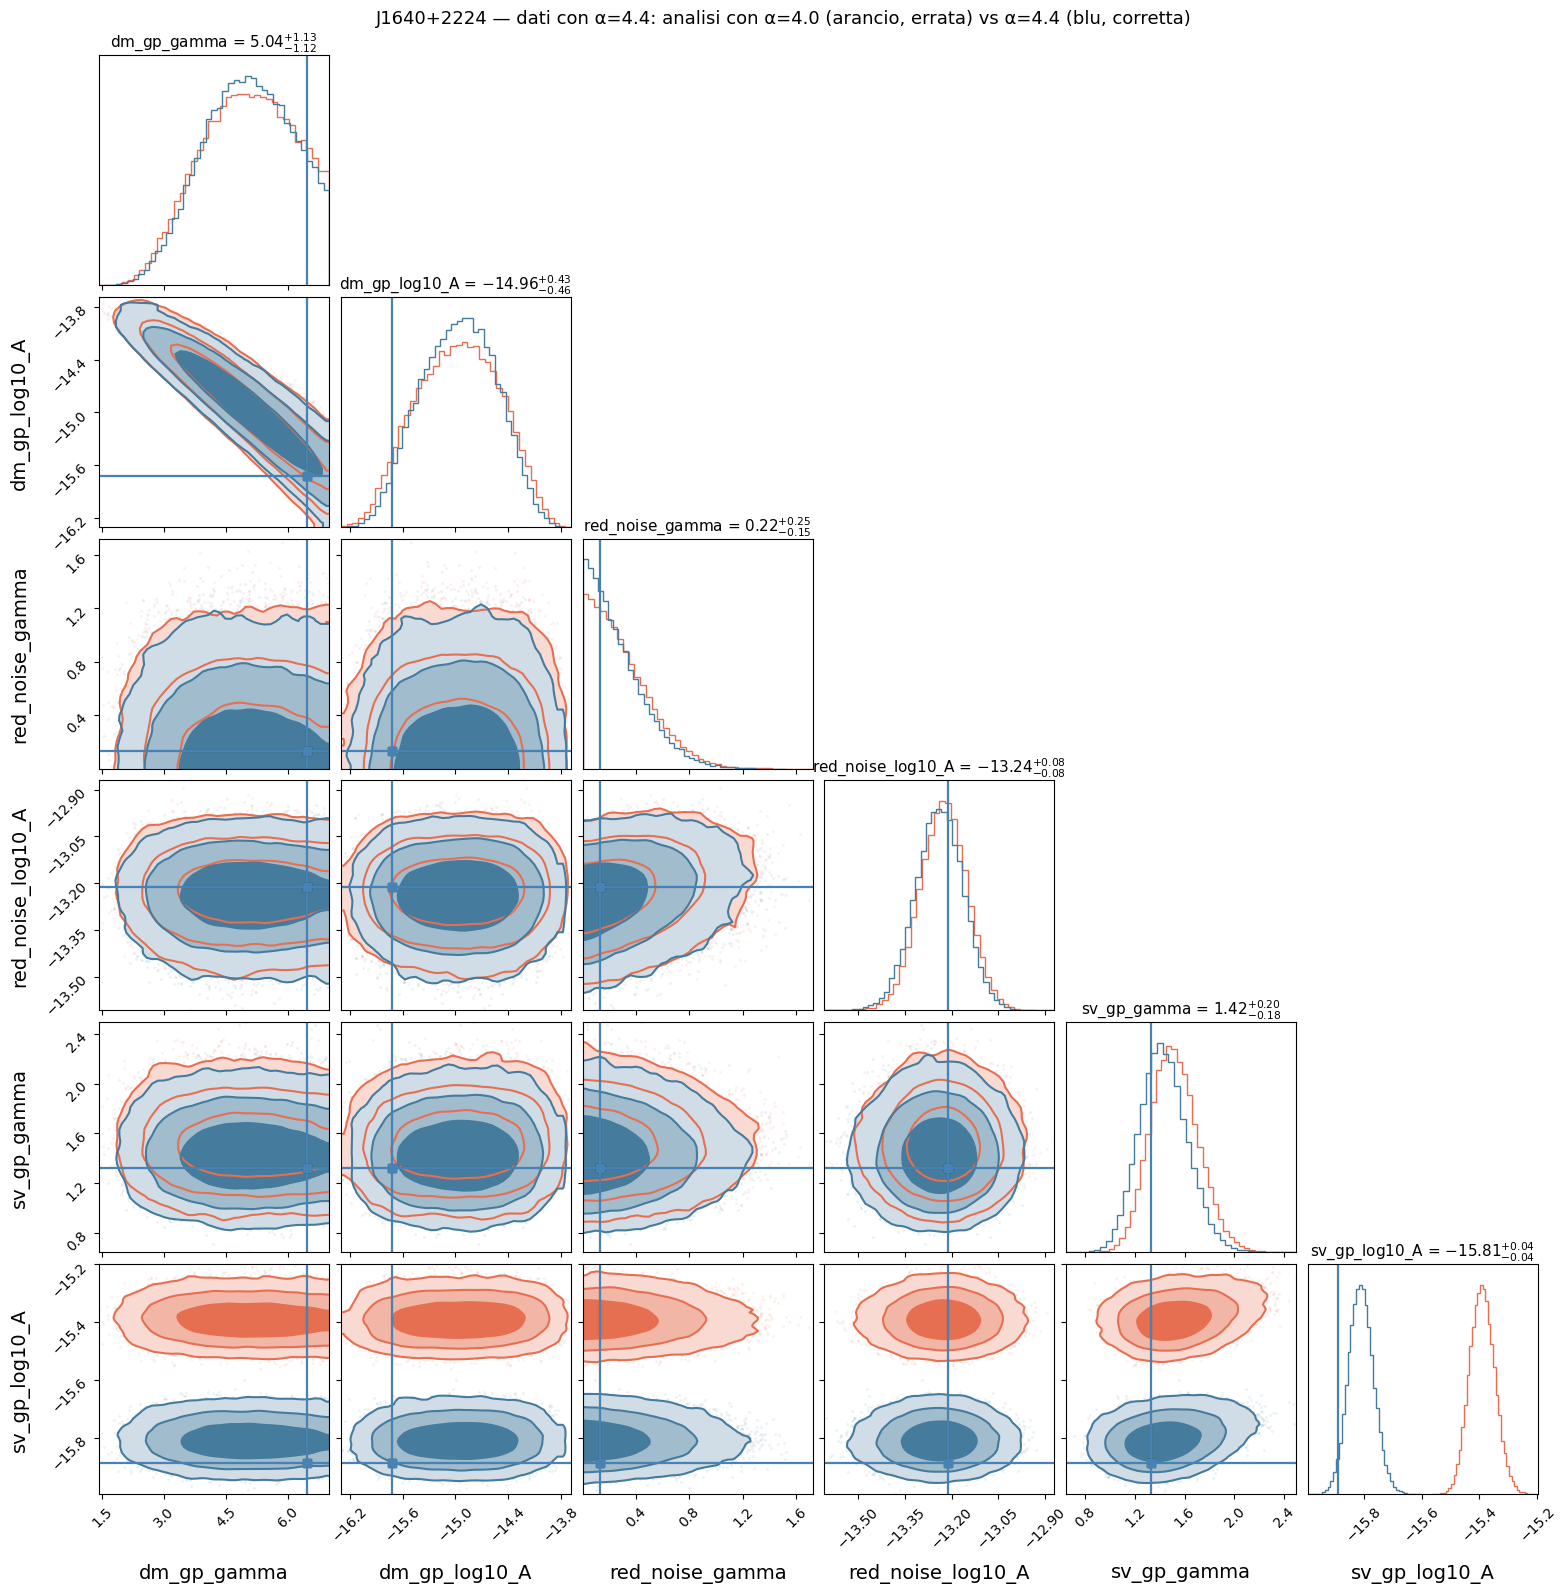

In [19]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_sv44_ok.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_sv44_ok.params]

# modello errato, alpha = 4.0 — arancio scuro
fig = corner.corner(
    chain_sim_sv44,
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#E76F51',
)

# modello corretto, alpha = 4.4 — blu medio
corner.corner(
    chain_sim_sv44_ok,
    labels=clean_labels,
    truths=truth_values,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#457B9D',
    fig=fig
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — dati con α=4.4: analisi con α=4.0 (arancio, errata) vs α=4.4 (blu, corretta)', fontsize=13, y=1.00)
fig.savefig('corner_sim_sv44_errato_vs_corretto.png', dpi=150, bbox_inches='tight')

### Quando anche il notebook 08 sarà finito

Aggiungere qui un confronto a tre su `sv_gp_log10_A`: α fisso corretto (blu), α fisso errato (arancio), α libero (blu petrolio). La larghezza della posterior con α libero rispetto a quella con α fisso corretto misura il prezzo, in precisione, di non conoscere l'indice cromatico.